<a href="https://colab.research.google.com/github/Ayush28-ai/Ayush28-ai/blob/main/Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import itertools

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
import missingno as msno
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import iplot

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import layers

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras import Model
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from zipfile import ZipFile

# loading the temp.zip and creating a zip object
with ZipFile("/content/PetData.zip", 'r') as zObject:

    # Extracting specific file in the zip
    # into a specific location.
    zObject.extractall(path='.')
zObject.close()

In [ ]:
# train_data_dir = '/content/PetData/Master Folder/train'
# valid_data_dir = '/content/PetData/Master Folder/valid'
# test_data_dir = '/content/PetData/Master Folder/test'

data_dir = '/content/PetData/'


ds_name = 'Pets Facial Expression'

In [ ]:
# Generate data paths with labels

def generate_data_paths(data_dir):

    filepaths = []
    labels = []

    folds = os.listdir(data_dir)
    for fold in folds:
        if fold == 'Master Folder':
            continue

        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)

    return filepaths, labels


filepaths, labels = generate_data_paths(data_dir)

In [ ]:
def create_df(filepaths, labels):

    Fseries = pd.Series(filepaths, name= 'filepaths')
    Lseries = pd.Series(labels, name='labels')
    df = pd.concat([Fseries, Lseries], axis= 1)
    return df

df = create_df(filepaths, labels)
df

,filepaths,labels
0,/content/PetData/Angry/aug-6-09.jpg,Angry
1,/content/PetData/Angry/aug-130-72.jpg,Angry
2,/content/PetData/Angry/aug-80-08.jpg,Angry
3,/content/PetData/Angry/aug-142-85.jpg,Angry
4,/content/PetData/Angry/aug-96-28.jpg,Angry
...,...,...
995,/content/PetData/Other/aug-59-20.jpg,Other
996,/content/PetData/Other/aug-92-58.jpg,Other
997,/content/PetData/Other/aug-120-36.jpg,Other
998,/content/PetData/Other/aug-5-08.jpg,Other


In [ ]:
# train dataframe
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)

# valid and test dataframe
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

In [ ]:
# crobed image size
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Recommended : use custom function for test data batch size, else we can use normal batch size.
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

dummy_df

,filepaths,labels
131,/content/PetData/Angry/91.jpg,Angry
203,/content/PetData/Angry/aug-58-76.jpg,Angry
50,/content/PetData/Angry/28.jpg,Angry
585,/content/PetData/happy/aug-125-044.jpg,happy
138,/content/PetData/Angry/05.jpg,Angry
...,...,...
79,/content/PetData/Angry/aug-18-25.jpg,Angry
177,/content/PetData/Angry/aug-65-83.jpg,Angry
657,/content/PetData/happy/aug-38-050.jpg,happy
210,/content/PetData/Angry/78.jpg,Angry


In [ ]:


# This function which will be used in image data generator for data augmentation, it just take the image and return it again.
def scalar(img):
    return img

tr_gen = ImageDataGenerator(preprocessing_function= scalar,
                           rotation_range=20,
                           width_shift_range=0.15,
                           height_shift_range=0.15,
                           brightness_range=[0.8,1.2],
                           zoom_range=0.15,
                           horizontal_flip=True)
                          #  vertical_flip=True)

ts_gen = ImageDataGenerator(preprocessing_function= scalar,
                           rotation_range=20,
                           width_shift_range=0.15,
                           height_shift_range=0.15,
                           brightness_range=[0.8,1.2],
                           zoom_range=0.15,
                           horizontal_flip=True)
                          #  vertical_flip=True)

train_gen = tr_gen.flow_from_dataframe(train_df,
                                       x_col= 'filepaths',
                                       y_col= 'labels',
                                       target_size= img_size,
                                       class_mode= 'categorical',
                                       color_mode= 'rgb',
                                       shuffle= True,
                                       batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df,
                                       x_col= 'filepaths',
                                       y_col= 'labels',
                                       target_size= img_size,
                                       class_mode= 'categorical',
                                       color_mode= 'rgb',
                                       shuffle= True,
                                       batch_size= batch_size)

# Note: we will use custom test_batch_size, and make shuffle= false
test_gen = ts_gen.flow_from_dataframe(test_df,
                                      x_col= 'filepaths',
                                      y_col= 'labels',
                                      target_size= img_size,
                                      class_mode= 'categorical',
                                      color_mode= 'rgb',
                                      shuffle= False,
                                      batch_size= test_batch_size)

Found 800 validated image filenames belonging to 4 classes.
Found 120 validated image filenames belonging to 4 classes.
Found 80 validated image filenames belonging to 4 classes.


Number of samples in train_gen: 800
Number of batches per epoch: 50
Batch shape: (16, 224, 224, 3)


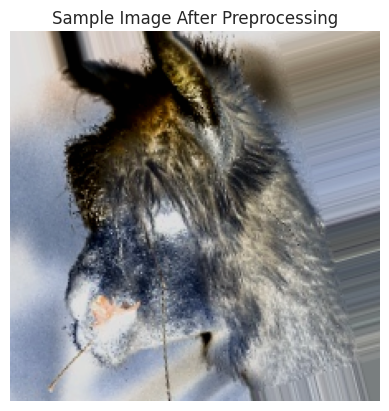

[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]


{'Angry': 0, 'Other': 1, 'Sad': 2, 'happy': 3}

In [ ]:
print("Number of samples in train_gen:", train_gen.samples)
print("Number of batches per epoch:", train_gen.samples // train_gen.batch_size)

# Get a batch of images and labels
sample_batch, labels = next(train_gen)  # Extract the first batch

# Print the shape of the batch
print("Batch shape:", sample_batch.shape)

# Get a batch of images
sample_batch, _ = next(train_gen)

# Convert back to original scale (0-255)
image = sample_batch[1] * 255
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.astype(np.uint8)  # Convert to integer format

# Display image
plt.imshow(image)
plt.axis("off")
plt.title("Sample Image After Preprocessing")
plt.show()
print(labels)
train_gen.class_indices

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, Multiply, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Set parameters
IMG_SIZE = (224, 224)  # Resize images
BATCH_SIZE = 16
CLASS_NAMES = ['Angry', 'Sad', 'happy', 'Other']
NUM_CLASSES = len(CLASS_NAMES)

# Spatial Attention Module
def spatial_attention(input_tensor):
    x = Conv2D(1, kernel_size=3, padding='same', activation='sigmoid')(input_tensor)
    return Multiply()([input_tensor, x])

# Load EfficientNetB0 model
def build_model():
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)  # EfficientNet backbone
    x = spatial_attention(x)  # Add Spatial Attention
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(NUM_CLASSES, activation='softmax')(x)  # Output layer

    model = Model(inputs, x)
    return model

# Load PET Data Images
#train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)  # Normalization
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=30,       # Rotate images by up to 30 degrees
#     zoom_range=0.2,          # Random zoom
#     width_shift_range=0.2,   # Horizontal shift
#     height_shift_range=0.2,  # Vertical shift
#     brightness_range=[0.7, 1.3],  # Vary brightness
#     horizontal_flip=True,     # Flip images horizontally
#     validation_split=0.2      # Keep 20% for validation
# )


# train_gen = train_datagen.flow_from_directory(
#     '/content/PetData/Master Folder/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training')

# valid_gen = train_datagen.flow_from_directory(
#     '/content/PetData/Master Folder/valid', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation')

# Compile model
model = build_model()
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_gen, validation_data=valid_gen, epochs=50, verbose=1)

# Save the trained model
model.save('EfficientNet_B0_PetData_Emotion.h5')

# Evaluate the model
val_loss, val_acc = model.evaluate(valid_gen)
print(f"Validation Accuracy: {val_acc:.4f}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 743ms/step - accuracy: 0.2890 - loss: 1.7765 - val_accuracy: 0.5333 - val_loss: 1.2561
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 289ms/step - accuracy: 0.4831 - loss: 1.1905 - val_accuracy: 0.5750 - val_loss: 1.1828
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 284ms/step - accuracy: 0.5719 - loss: 1.0188 - val_accuracy: 0.6750 - val_loss: 1.0631
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step - accuracy: 0.6279 - loss: 0.8622 - val_accuracy: 0.7583 - val_loss: 0.9790
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 286ms/step - accuracy: 0.6724 - loss: 0.8514 - val_accuracy: 0.7333 - val_loss: 0.8513
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step - accuracy: 0.7479 - loss: 0.6802 - val_accuracy: 0.7667 - val_loss: 0.7859
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 287ms/step - accuracy: 0.7472 - loss: 0.6765 - val_accuracy: 0.8083 - val_loss: 0.7022
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 284ms/step - accuracy: 0.7459 - loss: 0.6449 - val_accu

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.9721 - loss: 0.0722
Validation Accuracy: 0.9750


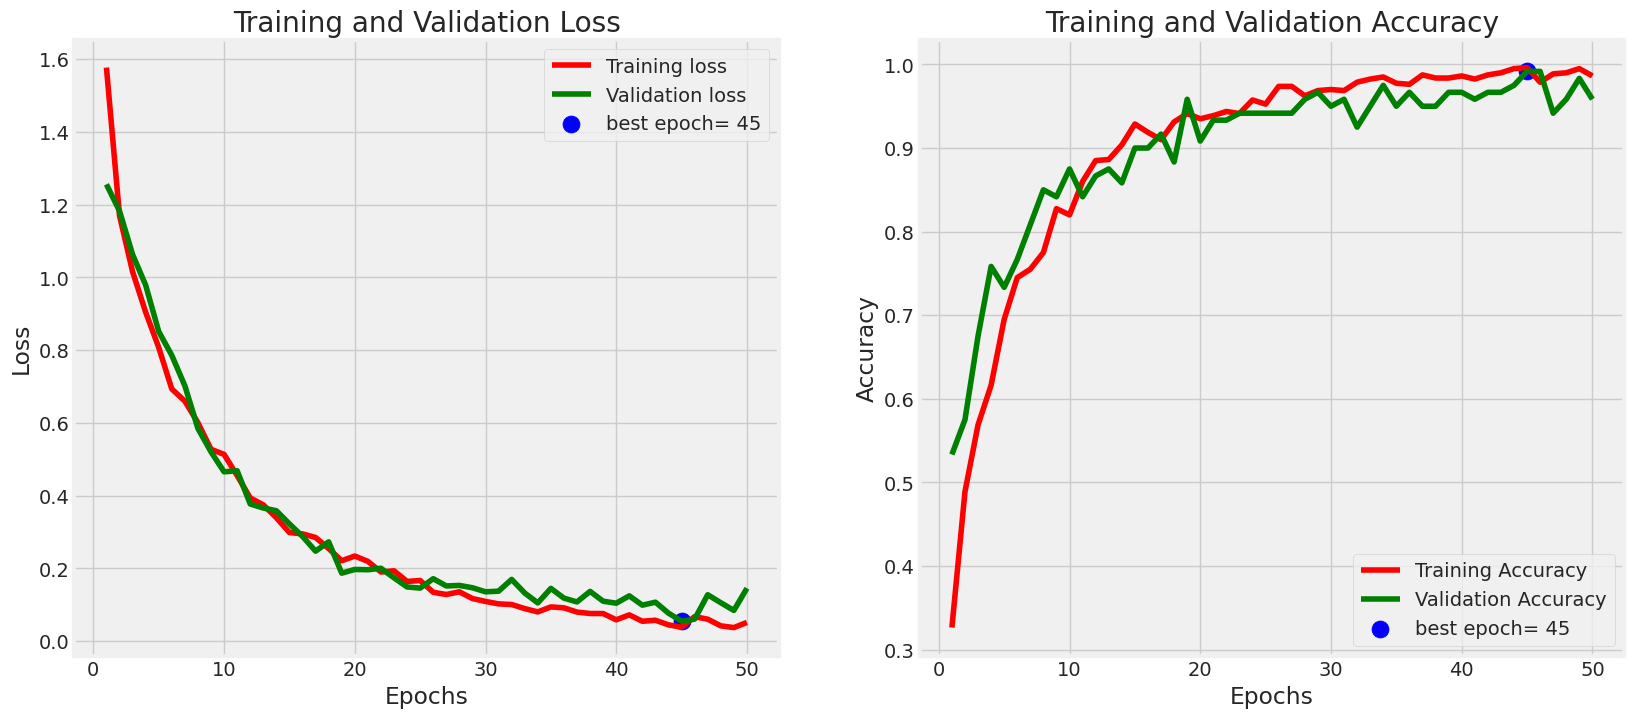

In [ ]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [ ]:
y_pred

array([0, 0, 0, 0, 2, 1, 0, 1, 2, 0, 1, 3, 3, 1, 1, 0, 0, 3, 3, 2, 1, 2,
       1, 1, 0, 1, 2, 3, 0, 1, 3, 0, 2, 3, 0, 2, 2, 1, 1, 2, 3, 1, 1, 3,
       1, 1, 2, 1, 3, 1, 1, 1, 3, 1, 0, 1, 0, 2, 1, 0, 2, 1, 2, 1, 1, 0,
       2, 3, 2, 1, 1, 2, 3, 2, 2, 3, 1, 2, 1, 1])

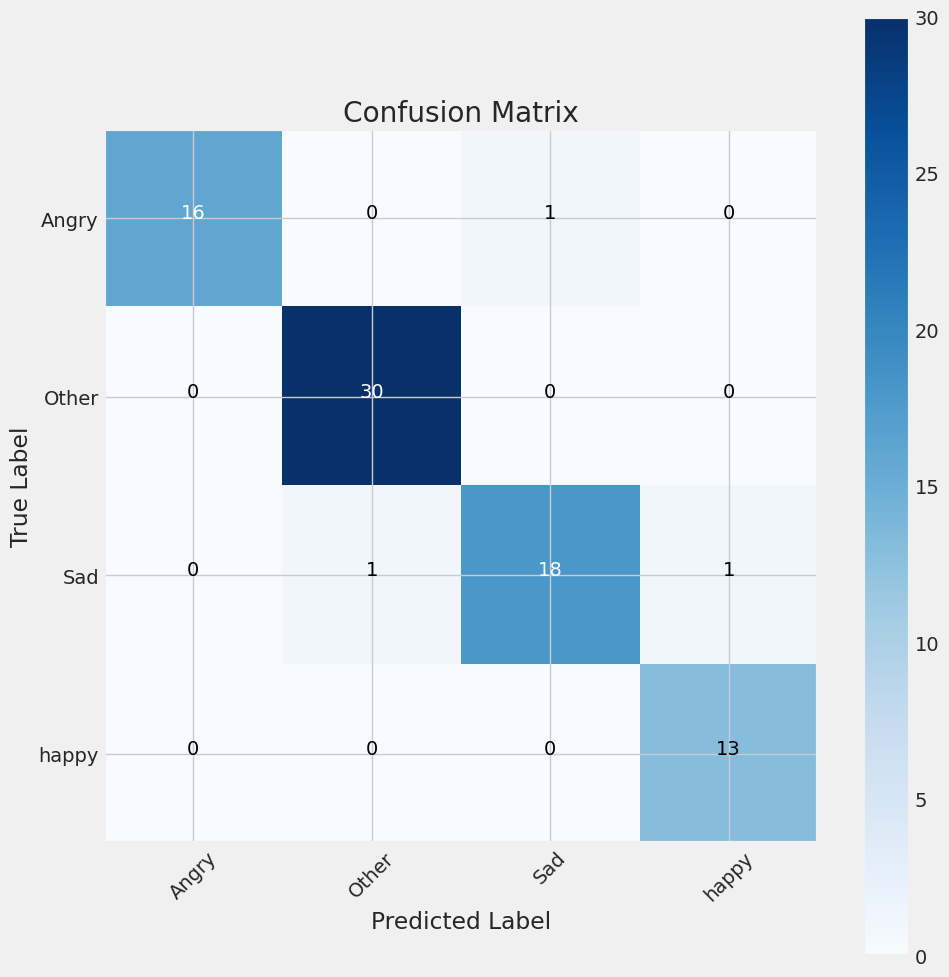

In [ ]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [ ]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

       Angry       1.00      0.94      0.97        17
       Other       0.97      1.00      0.98        30
         Sad       0.95      0.90      0.92        20
       happy       0.93      1.00      0.96        13

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


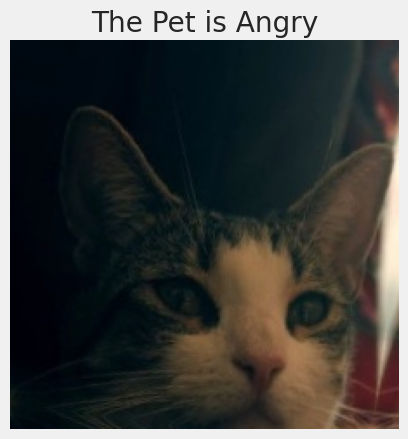

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_and_display(image_path, model):

    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)

    class_indices = train_gen.class_indices
    class_labels = list(class_indices.keys())
    predicted_class_label = class_labels[predicted_class_index]

    plt.imshow(img)
    plt.axis('off')
    if predicted_class_label == 'Other':
        plt.title(f"The pet is normal")
    else:
        plt.title(f"The Pet is {predicted_class_label}")
    plt.show()

model.load_weights('/content/EfficientNet_B0_PetData_Emotion.h5')

class_labels = ['Angry', 'Other', 'Sad', 'Happy']

# Replace 'path_to_test_image' with the path to the image you want to test
image_path_to_test = '/content/PetData/Angry/aug-119-57.jpg'
predict_and_display(image_path_to_test, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


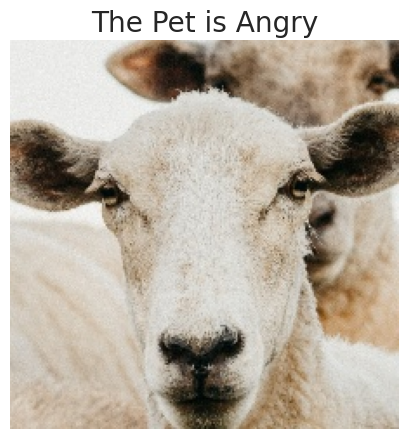

In [ ]:
image_path_to_test = '/content/PetData/Master Folder/test/happy/048.jpg'
predict_and_display(image_path_to_test, model)

In [ ]:
with ZipFile("/content/trim.zip", 'r') as zObject:

    # Extracting specific file in the zip
    # into a specific location.
    zObject.extractall(path='./inference')
zObject.close()

In [ ]:
inf_filepaths, inf_labels = generate_data_paths('/content/inference/trim')

In [ ]:
def create_df(filepaths, labels):

    Fseries = pd.Series(filepaths, name= 'filepaths')
    Lseries = pd.Series(labels, name='labels')
    df = pd.concat([Fseries, Lseries], axis= 1)
    return df

df = create_df(inf_filepaths, inf_labels)
df

,filepaths,labels
0,/content/inference/trim/Sad/6251153_8ee7302bc3...,Sad
1,/content/inference/trim/Sad/2659620_b8141b1c92...,Sad
2,/content/inference/trim/Sad/8039427_33a980a87b...,Sad
3,/content/inference/trim/Sad/11032976_e24fcd724...,Sad
4,/content/inference/trim/Sad/4755660_527866f01c...,Sad
...,...,...
79,/content/inference/trim/Angry/10325720_7181f50...,Angry
80,/content/inference/trim/Angry/17025473_6239011...,Angry
81,/content/inference/trim/Angry/14275334_bae466a...,Angry
82,/content/inference/trim/Angry/3521138_363be385...,Angry


In [ ]:
test_df = df

In [ ]:
# crobed image size
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Recommended : use custom function for test data batch size, else we can use normal batch size.
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

test_batch_size

42

In [ ]:
test_gen = ts_gen.flow_from_dataframe(test_df,
                                      x_col= 'filepaths',
                                      y_col= 'labels',
                                      target_size= img_size,
                                      class_mode= 'categorical',
                                      color_mode= 'rgb',
                                      shuffle= False,
                                      batch_size= test_batch_size)

Found 84 validated image filenames belonging to 4 classes.


In [ ]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step


In [ ]:
y_pred

array([1, 0, 3, 3, 2, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 3, 3, 0, 3, 0, 2, 3,
       3, 3, 3, 0, 2, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 0, 3, 3, 1,
       2, 2, 3, 2, 3, 2, 1, 1, 3, 3, 3, 3, 3, 3, 1, 3, 2, 3, 2, 0, 1, 2,
       3, 2, 2, 3, 0, 3, 1, 3, 3, 3, 3, 3, 3, 3, 1, 2, 3, 3])

In [ ]:
unique_values, counts = np.unique(y_pred, return_counts=True)

# Display result
print("Values:", unique_values)
print("Frequencies:", counts)

Values: [0 1 2 3]
Frequencies: [ 7 10 18 49]


In [ ]:
print(counts[3]/y_pred.shape[0]*100)

80.47210300429185


In [ ]:
test_gen.classes

[2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [ ]:
g_dict = train_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [800, 84]